# Score Kaggle 200K Humor Texts with `humor-distilbert`

This notebook downloads the Kaggle dataset **200K SHORT TEXTS FOR HUMOR DETECTION**, passes every text through Hugging Face model [`iamahmadyasin/humor-distilbert`](https://huggingface.co/iamahmadyasin/humor-distilbert), and stores the model's predicted humor score in a new dataset column named `score`.

The model is a DistilBERT regression model. Its model card says it outputs one scalar humor score on a 0-11 scale. The model is trained on English Reddit jokes and humor is subjective, so treat these scores as model predictions, not ground truth.

## 1. Imports and local M2 Pro setup

This cell uses the Apple GPU through PyTorch MPS if your local runtime exposes it. On your earlier macOS 13.3 setup, PyTorch reported `MPS built: True` but `MPS available: False`, so this notebook also has a CPU fallback.

In [2]:
from pathlib import Path
import os
import platform
import warnings

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

warnings.filterwarnings("ignore", category=FutureWarning)

KAGGLE_DATASET = "deepcontractor/200k-short-texts-for-humor-detection"
MODEL_NAME = "iamahmadyasin/humor-distilbert"

DATA_DIR = Path("datasets/humor_200k")
OUTPUT_DIR = Path("outputs/humor_200k_scoring")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The model card's usage example uses max_length=128.
MAX_LENGTH = 128

# Leave as None to choose based on the selected device.
BATCH_SIZE = None

# The model is described as a 0-11 regressor, but regression heads can emit small out-of-range values.
# Keep raw model outputs by default; set True if you want all saved scores clipped to [0, 11].
CLIP_TO_0_11 = False

# Checkpoint scores every N batches so a long run can resume after interruption.
CHECKPOINT_EVERY_BATCHES = 25
FORCE_RECOMPUTE = False

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if BATCH_SIZE is None:
    if DEVICE.type == "cuda":
        BATCH_SIZE = 256
    elif DEVICE.type == "mps":
        BATCH_SIZE = 128
    else:
        BATCH_SIZE = 32

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

mps_backend = getattr(torch.backends, "mps", None)
print("Python:", platform.python_version())
print("macOS:", platform.mac_ver())
print("Machine:", platform.machine())
print("PyTorch:", torch.__version__)
if mps_backend is not None:
    print("MPS built:", mps_backend.is_built())
    print("MPS available:", mps_backend.is_available())
print("Selected device:", DEVICE)
print("Batch size:", BATCH_SIZE)

Python: 3.12.13
macOS: ('26.5.2', ('', '', ''), 'arm64')
Machine: arm64
PyTorch: 2.11.0
MPS built: True
MPS available: True
Selected device: mps
Batch size: 128


## 2. Download the Kaggle dataset

This uses `kagglehub.dataset_download`. If Kaggle authentication is needed, set your Kaggle credentials in the environment used by this notebook, or place `kaggle.json` in the standard Kaggle location. Public datasets often download without extra work, but Kaggle may still require credentials depending on your setup.

In [3]:
def download_kaggle_dataset(dataset_slug, target_dir):
    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "kagglehub is not installed in this environment. Install it with `pip install kagglehub`, "
            "or manually download the Kaggle dataset into datasets/humor_200k/."
        ) from exc

    path = Path(kagglehub.dataset_download(dataset_slug))
    print("Downloaded/cached Kaggle dataset at:", path)
    return path


kaggle_path = download_kaggle_dataset(KAGGLE_DATASET, DATA_DIR)
csv_files = sorted(kaggle_path.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found under {kaggle_path}")

print("CSV files found:")
for i, csv_path in enumerate(csv_files):
    print(f"{i}: {csv_path}")

# The dataset is expected to contain one primary CSV. If Kaggle changes the package,
# pick the largest CSV as the likely data file.
DATA_CSV = max(csv_files, key=lambda p: p.stat().st_size)
print("Using CSV:", DATA_CSV)

100%|██████████| 6.00M/6.00M [00:02<00:00, 2.90MB/s]

Extracting files...
Downloaded/cached Kaggle dataset at: /Users/xinsui/.cache/kagglehub/datasets/deepcontractor/200k-short-texts-for-humor-detection/versions/1
CSV files found:
0: /Users/xinsui/.cache/kagglehub/datasets/deepcontractor/200k-short-texts-for-humor-detection/versions/1/dataset.csv
Using CSV: /Users/xinsui/.cache/kagglehub/datasets/deepcontractor/200k-short-texts-for-humor-detection/versions/1/dataset.csv


## 3. Load the dataset and identify the text column

In [4]:
df = pd.read_csv(DATA_CSV)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

def infer_text_column(frame):
    candidates = ["text", "sentence", "short_text", "statement", "content", "joke", "body"]
    lower_to_original = {col.lower(): col for col in frame.columns}
    for candidate in candidates:
        if candidate in lower_to_original:
            return lower_to_original[candidate]

    object_cols = [col for col in frame.columns if frame[col].dtype == "object" or str(frame[col].dtype).startswith("string")]
    if not object_cols:
        raise ValueError("Could not infer a text column: no string/object columns found.")

    # Pick the string column with the largest average non-null length.
    avg_lengths = {
        col: frame[col].dropna().astype(str).str.len().mean()
        for col in object_cols
    }
    return max(avg_lengths, key=avg_lengths.get)


TEXT_COLUMN = infer_text_column(df)
print("Text column:", TEXT_COLUMN)

texts = df[TEXT_COLUMN].fillna("").astype(str).tolist()
empty_count = sum(text.strip() == "" for text in texts)
print("Rows:", len(texts))
print("Empty texts:", empty_count)

Shape: (200000, 2)
Columns: ['text', 'humor']


,text,humor
0,"Joe biden rules out 2020 bid: 'guys, i'm not r...",False
1,Watch: darvish gave hitter whiplash with slow ...,False
2,What do you call a turtle without its shell? d...,True
3,5 reasons the 2016 election feels so personal,False
4,"Pasco police shot mexican migrant from behind,...",False


Text column: text
Rows: 200000
Empty texts: 0


## 4. Load the Hugging Face humor model

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(DEVICE)
model.eval()

print("Model:", MODEL_NAME)
print("num_labels:", model.config.num_labels)
print("problem_type:", getattr(model.config, "problem_type", None))
print("Device:", DEVICE)

config.json:   0%|          | 0.00/630 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model: iamahmadyasin/humor-distilbert
num_labels: 1
problem_type: regression
Device: mps


## 5. Score every row

The model returns one regression logit per text. That scalar is saved into the new `score` column. A NumPy checkpoint is written during inference so you can resume if the kernel stops.

In [6]:
scores_path = OUTPUT_DIR / "humor_scores_checkpoint.npy"
metadata_path = OUTPUT_DIR / "scoring_metadata.json"

metadata = {
    "dataset": KAGGLE_DATASET,
    "data_csv": str(DATA_CSV),
    "rows": len(df),
    "text_column": TEXT_COLUMN,
    "model": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "clip_to_0_11": CLIP_TO_0_11,
}

def load_or_init_scores():
    if FORCE_RECOMPUTE or not scores_path.exists() or not metadata_path.exists():
        return np.full(len(df), np.nan, dtype=np.float32)

    with metadata_path.open() as f:
        previous_metadata = __import__("json").load(f)
    if previous_metadata != metadata:
        print("Existing checkpoint metadata does not match current run; starting over.")
        return np.full(len(df), np.nan, dtype=np.float32)

    loaded = np.load(scores_path)
    if loaded.shape[0] != len(df):
        print("Existing checkpoint length does not match current dataset; starting over.")
        return np.full(len(df), np.nan, dtype=np.float32)
    print(f"Loaded checkpoint with {np.isfinite(loaded).sum():,}/{len(loaded):,} scored rows.")
    return loaded.astype(np.float32)


scores = load_or_init_scores()

def save_checkpoint(scores_array):
    np.save(scores_path, scores_array)
    with metadata_path.open("w") as f:
        __import__("json").dump(metadata, f, indent=2)


@torch.inference_mode()
def score_batch(batch_texts):
    encoded = tokenizer(
        list(batch_texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
    logits = model(**encoded).logits.squeeze(-1)
    batch_scores = logits.detach().cpu().float().numpy()
    if CLIP_TO_0_11:
        batch_scores = np.clip(batch_scores, 0.0, 11.0)
    return batch_scores.astype(np.float32)


pending_indices = np.flatnonzero(~np.isfinite(scores))
print(f"Rows still needing scores: {len(pending_indices):,}")

batches_completed = 0
for start in tqdm(range(0, len(pending_indices), BATCH_SIZE), desc="Scoring humor"):
    batch_indices = pending_indices[start : start + BATCH_SIZE]
    batch_texts = [texts[i] for i in batch_indices]
    scores[batch_indices] = score_batch(batch_texts)
    batches_completed += 1

    if batches_completed % CHECKPOINT_EVERY_BATCHES == 0:
        save_checkpoint(scores)

save_checkpoint(scores)
print(f"Scored rows: {np.isfinite(scores).sum():,}/{len(scores):,}")
print("Score range:", float(np.nanmin(scores)), "to", float(np.nanmax(scores)))

Rows still needing scores: 200,000


Scoring humor:   0%|          | 0/1563 [00:00<?, ?it/s]

Scored rows: 200,000/200,000
Score range: 0.013325130566954613 to 7.856147289276123


## 6. Save the scored dataset

In [7]:
scored_df = df.copy()
scored_df["score"] = scores

output_csv = OUTPUT_DIR / "200k_short_texts_for_humor_detection_scored.csv"
scored_df.to_csv(output_csv, index=False)
print("Saved scored CSV:", output_csv)

try:
    output_parquet = OUTPUT_DIR / "200k_short_texts_for_humor_detection_scored.parquet"
    scored_df.to_parquet(output_parquet, index=False)
    print("Saved scored Parquet:", output_parquet)
except Exception as exc:
    print("Parquet save skipped:", exc)

display(scored_df.head())
display(scored_df["score"].describe().to_frame("score"))

Saved scored CSV: outputs/humor_200k_scoring/200k_short_texts_for_humor_detection_scored.csv
Saved scored Parquet: outputs/humor_200k_scoring/200k_short_texts_for_humor_detection_scored.parquet


,text,humor,score
0,"Joe biden rules out 2020 bid: 'guys, i'm not r...",False,0.679970
1,Watch: darvish gave hitter whiplash with slow ...,False,0.421646
2,What do you call a turtle without its shell? d...,True,0.895106
3,5 reasons the 2016 election feels so personal,False,1.223488
4,"Pasco police shot mexican migrant from behind,...",False,0.837635


,score
count,200000.000000
mean,1.099934
std,0.740772
min,0.013325
25%,0.615355
50%,0.875954
75%,1.326818
max,7.856147


## 7. Quick sanity plots

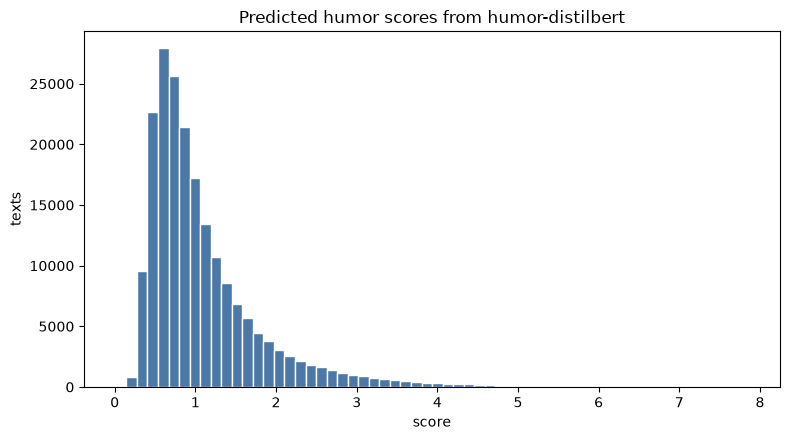

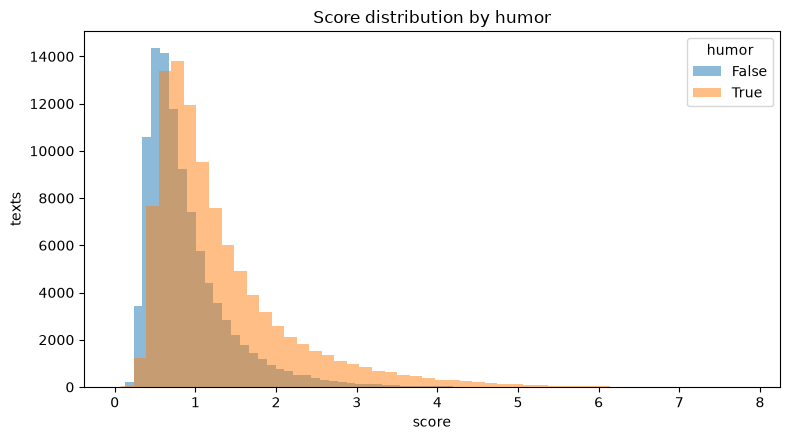

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(scored_df["score"].dropna(), bins=60, color="#4c78a8", edgecolor="white")
ax.set_title("Predicted humor scores from humor-distilbert")
ax.set_xlabel("score")
ax.set_ylabel("texts")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "score_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

# If the Kaggle dataset includes a binary humor label, compare score distributions by that label.
label_candidates = [col for col in scored_df.columns if col.lower() in {"humor", "is_humor", "label", "class"}]
if label_candidates:
    label_col = label_candidates[0]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label_value, group in scored_df.groupby(label_col):
        ax.hist(group["score"].dropna(), bins=50, alpha=0.5, label=str(label_value))
    ax.set_title(f"Score distribution by {label_col}")
    ax.set_xlabel("score")
    ax.set_ylabel("texts")
    ax.legend(title=label_col)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "score_distribution_by_label.png", dpi=180, bbox_inches="tight")
    plt.show()

## Outputs

The main scored dataset is saved here:

- `outputs/humor_200k_scoring/200k_short_texts_for_humor_detection_scored.csv`

The file contains all original columns plus the new `score` column.